<a href="https://colab.research.google.com/github/Mogu-code/DataScience/blob/main/FDS_pandas_and_np_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PANDAS AND NUMPY**

In [ ]:
import pandas as pd
import numpy as np

# WITH NONE DATATYPE IN NUMPY

In [ ]:
a=np.array([1,2,3,None,5]) #1d array w/ list as parameter,Because of None, NumPy cannot keep numeric dtype.
print(a.dtype)

object


In [ ]:
a.sum()

TypeError: unsupported operand type(s) for +: 'int' and 'NoneType'

# WITH NP.NAN

In [ ]:
# Correct way: using np.nan
a=np.array([1,2,3,np.nan,5]) #Value	Meaning	Works with NumPy math?
print(a.dtype)
#None	Python null object	No
#np.nan	Numeric missing value	 Yes

float64


In [ ]:
a.sum()

np.float64(nan)

In [ ]:
print(a.sum())

nan


In [ ]:
# ignores nan → 11, ignores nan → 1
print(np.nansum(a),np.nanmin(a),np.nanmean(a),np.nanmax(a))

11.0 1.0 2.75 5.0


# isnull(),notnull()

In [ ]:
data_with_missing_val=pd.Series([1,2,np.nan,'hello',None])
data_with_missing_val
print(data_with_missing_val.isnull())

0    False
1    False
2     True
3    False
4     True
dtype: bool


In [ ]:
#obtaining values which are not null
data_with_missing_val[data_with_missing_val.notnull()]

,0
0,1
1,2
3,hello


# PANDAS

In [ ]:
#dictionary of list
dict_={
    'First':[90,90,np.nan,95],
    'Second':[33,45,56,np.nan],
    'Third':[np.nan,45,80,98],
    'Fourth':[50,60,60,70],
    'Fifth':[33,45,56,None],
}
#create a df from dictionary of list,Turns dictionary into table.
df=pd.DataFrame(dict_)
#to check missing data
df.isnull()


,First,Second,Third,Fourth,Fifth
0,False,False,True,False,False
1,False,False,False,False,False
2,True,False,False,False,False
3,False,True,False,False,True


# WORKING WITH NaN
Pandas automatically converts None → NaN internally.\
None == NaN

In [ ]:
# Check non-missing values in one column
df['First'].notna()

,First
0,True
1,True
2,False
3,True


In [ ]:
#creating new data frame and replacing nan over there
df1=df.fillna(1000)
df1

,First,Second,Third,Fourth,Fifth
0,90.0,33.0,1000.0,50,33.0
1,90.0,45.0,45.0,60,45.0
2,1000.0,56.0,80.0,60,56.0
3,95.0,1000.0,98.0,70,1000.0


In [ ]:
# Replace missing values with 0
#inplace=True → modifies original dfotherwise it returns a new dataframe

df.fillna(0,inplace=True)
df

,First,Second,Third,Fourth,Fifth
0,90.0,33.0,0.0,50,33.0
1,90.0,45.0,45.0,60,45.0
2,0.0,56.0,80.0,60,56.0
3,95.0,0.0,98.0,70,0.0


In [ ]:
#starting over with those nan values,fill missing with previos ones
df=pd.DataFrame(dict_)
print(df)

   First  Second  Third  Fourth  Fifth
0   90.0    33.0    NaN      50   33.0
1   90.0    45.0   45.0      60   45.0
2    NaN    56.0   80.0      60   56.0
3   95.0     NaN   98.0      70    NaN


# ffill(), bfill()
Forward fill = fill missing values using the previous row’s value\


In [ ]:
#backward fill()
# returns a new dataframe.
# It does NOT change original.
df.bfill()

,First,Second,Third,Fourth,Fifth
0,90.0,33.0,45.0,50,33.0
1,90.0,45.0,45.0,60,45.0
2,95.0,56.0,80.0,60,56.0
3,95.0,NaN,98.0,70,NaN


In [ ]:
df.ffill()
# df.fillna(method='pad') # same as ffill()
# returns a new dataframe.
# It does NOT change original.
# To actually change df
# df = df.ffill()
# OR
# df.ffill(inplace=True)

,First,Second,Third,Fourth,Fifth
0,90.0,33.0,NaN,50,33.0
1,90.0,45.0,45.0,60,45.0
2,90.0,56.0,80.0,60,56.0
3,95.0,56.0,98.0,70,56.0


In [ ]:
#The first row NaN stays NaN:
df.loc[0, 'Third']  # still NaN
# Because there is no previous value above row 0.

np.float64(nan)

# FILL USING REPLACE Instead of fillna().

In [ ]:
#previous values
df=pd.DataFrame(dict_)
print(df)

   First  Second  Third  Fourth  Fifth
0   90.0    33.0    NaN      50   33.0
1   90.0    45.0   45.0      60   45.0
2    NaN    56.0   80.0      60   56.0
3   95.0     NaN   98.0      70    NaN


fillna()\
Only works on missing values\

**replace()**\
Works on ANY value, not just NaN.\
You can replace:\
0 → 100
90 → 999
"Male" → "M"\
When to use replace() instead of fillna()?\
When missing values are stored as some number or string instead of NaN.

In [ ]:
#Replace every NaN in dataframe with -99, inplace= true hence replce og data
df.replace(to_replace=np.nan,value=-99,inplace=True)
df

,First,Second,Third,Fourth,Fifth
0,90.0,33.0,-99.0,50,33.0
1,90.0,45.0,45.0,60,45.0
2,-99.0,56.0,80.0,60,56.0
3,95.0,-99.0,98.0,70,-99.0


In [ ]:
df=pd.DataFrame(dict_)
df

,First,Second,Third,Fourth,Fifth
0,90.0,33.0,NaN,50,33.0
1,90.0,45.0,45.0,60,45.0
2,NaN,56.0,80.0,60,56.0
3,95.0,NaN,98.0,70,NaN


# dropna()
Drops any row that has even one NaN\
df.dropna(how='all')\
Drop row only if every column is NaN\
So rows with partial data stay.\
Default behavior\
dropna()  → remove row if ANY value missing
\\\\
If row was:\

[NaN, NaN, NaN, NaN, NaN]\

👉 dropped with how='all'\

But:\

[90, NaN, NaN, NaN, NaN]\

👉 NOT dropped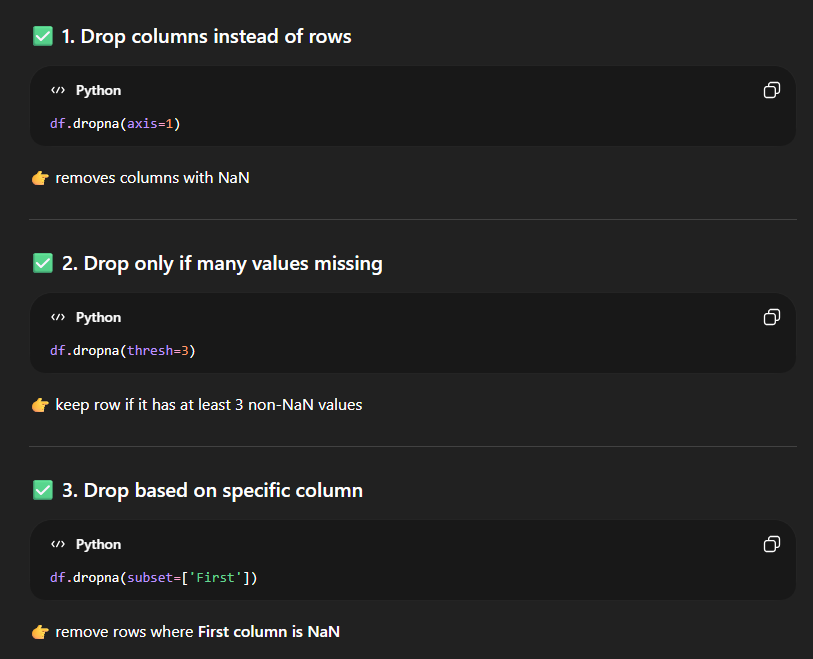

In [ ]:
df.dropna(inplace=True) #how='all' option can be used to drop only if all the values in a row are nan
print('After dropping')
df

After dropping


,First,Second,Third,Fourth,Fifth
1,90.0,45.0,45.0,60,45.0


# FILL WITH MEAN OF A COLUM FOR ENTIRE **DF**
df.mean() calculates mean of each numeric column

Pandas automatically fills each column’s NaN with its own mean

In [ ]:
df=pd.DataFrame(dict_)
print(df)

   First  Second  Third  Fourth  Fifth
0   90.0    33.0    NaN      50   33.0
1   90.0    45.0   45.0      60   45.0
2    NaN    56.0   80.0      60   56.0
3   95.0     NaN   98.0      70    NaN


In [ ]:
df.fillna(df.mean(),inplace=True)
df

,First,Second,Third,Fourth,Fifth
0,90.000000,33.000000,74.333333,50,33.000000
1,90.000000,45.000000,45.000000,60,45.000000
2,91.666667,56.000000,80.000000,60,56.000000
3,95.000000,44.666667,98.000000,70,44.666667


In [ ]:
df=pd.DataFrame(dict_)
print(df)

   First  Second  Third  Fourth  Fifth
0   90.0    33.0    NaN      50   33.0
1   90.0    45.0   45.0      60   45.0
2    NaN    56.0   80.0      60   56.0
3   95.0     NaN   98.0      70    NaN


In [ ]:
#Filling one column manually
means=df['First'].mean()
print(means)

91.66666666666667


In [ ]:
filled=df['First'].fillna(means)
df['First']=filled
df

,First,Second,Third,Fourth,Fifth
0,90.000000,33.0,NaN,50,33.0
1,90.000000,45.0,45.0,60,45.0
2,91.666667,56.0,80.0,60,56.0
3,95.000000,NaN,98.0,70,NaN


In [ ]:
filled=df['First'].fillna(means)
df['First']=filled
df

,First,Second,Third,Fourth,Fifth
0,90.000000,33.0,NaN,50,33.0
1,90.000000,45.0,45.0,60,45.0
2,91.666667,56.0,80.0,60,56.0
3,95.000000,NaN,98.0,70,NaN


In [ ]:
#fill from colum third to fifth with mean of their column and leave 1 n 2 untouched
df.fillna(df.mean()['Third':'Fifth'])

,First,Second,Third,Fourth,Fifth
0,90.000000,33.0,74.333333,50,33.000000
1,90.000000,45.0,45.000000,60,45.000000
2,91.666667,56.0,80.000000,60,56.000000
3,95.000000,NaN,98.000000,70,44.666667


# KNN Imputer (Machine Learning method)
It does:

👉 Find rows similar to the missing row\
👉 Use their values to estimate missing value

So it uses pattern similarity.

In [ ]:
!pip install -U scikit-learn

In [ ]:
nan=np.nan
X=[
    [1,2,nan],
    [3,4,3],
    [nan,6,5],
    [8,8,7]
]

In [ ]:
from sklearn.impute import KNNImputer

In [ ]:
imputer=KNNImputer(n_neighbors=2)
imputer.fit_transform(X)

array([[1. , 2. , 4. ],
       [3. , 4. , 3. ],
       [5.5, 6. , 5. ],
       [8. , 8. , 7. ]])

# DROP DEMONSTRATION
for showing:

✔ dropping rows
✔ dropping columns
✔ handling categorical missing values

dropna()\
dropna(subset=)\
drop columns with too many NaN

In [ ]:
import pandas as pd
import numpy as np
data={
    'Name' : ['Alice','Bob','Charlie','David','Eve'],
    'Age' : [25,np.nan,30,35,np.nan],
    'City' : ['New York','San Francisco',np.nan,'Chicago','Miami'],
    'Salary' : [50000,60000,70000,np.nan,80000],
    'Score':[np.nan,np.nan,np.nan,np.nan,np.nan]
}
df=pd.DataFrame(data)
df

,Name,Age,City,Salary,Score
0,Alice,25.0,New York,50000.0,NaN
1,Bob,NaN,San Francisco,60000.0,NaN
2,Charlie,30.0,NaN,70000.0,NaN
3,David,35.0,Chicago,NaN,NaN
4,Eve,NaN,Miami,80000.0,NaN


# ROW DROP

In [ ]:
#remove row that have any missing values
#note int his dataset, every row has at least 1 nan , so this would result in empty dataset

df_rows_dropped=df.dropna()
df_rows_dropped

,Name,Age,City,Salary,Score


# COLUMN DROP
REMOVE COLUMNS THAT HAVE ANY MISSING VALUES\
ONLY NAME WILL REMAIN BECAUSE IT IS ONLY COLUMN WITHOUT NAN

In [ ]:
df_cols_dropped=df.dropna(axis=1)
df_cols_dropped

,Name
0,Alice
1,Bob
2,Charlie
3,David
4,Eve


# SMART DROP
DROP ROWS ONLY IF AGE OR CITY IS MISSING

In [ ]:
df_subset_dropped=df.dropna(subset=['Age','City'])
df_subset_dropped

,Name,Age,City,Salary,Score
0,Alice,25.0,New York,50000.0,NaN
3,David,35.0,Chicago,NaN,NaN


# THRESHOLD DROP
drop columns that have more than 60% missing value, hence will romve score column

In [ ]:
limit=len(df)*0.4 #keep column iwth atleast 40% missing values
df_thresh_dropped=df.dropna(axis=1,thresh=limit)
df_thresh_dropped
#

,Name,Age,City,Salary
0,Alice,25.0,New York,50000.0
1,Bob,NaN,San Francisco,60000.0
2,Charlie,30.0,NaN,70000.0
3,David,35.0,Chicago,NaN
4,Eve,NaN,Miami,80000.0


In [ ]:
#create sample dataset with straetgic missing vlaues
#row1 missing science
# so on...
data={
    'Math':[85,90,78,92,np.nan],
    'Science':[88,np.nan,82,90,92],
    'English  ':[78,85,np.nan,92,90]
}
df=pd.DataFrame(data)
print("===========Originial dataset===========")
print(df)
print("\n"+"="*40+"\n")

===========Originial dataset===========
   Math  Science  English  
0  85.0     88.0       78.0
1  90.0      NaN       85.0
2  78.0     82.0        NaN
3  92.0     90.0       92.0
4   NaN     92.0       90.0




# PAIRWISE DELETION DEFAULT IN PADAS
WHEN CALCULATING MATH VS SCIENCE, IT ONLY IGNORE ROW1\
STILL USES ROW 2 N 4 CAUS EBOTH MATH N SCIENCE ARE PRESENT\
It uses rows where those two exist.\
Math–Science → rows 0,2,3

Math–English → rows 0,1,3

Science–English → rows 0,3,4

In [ ]:
pairwise_corr=df.corr()
print("===========Pairwise correlation matrix (pairwise deletion)===========")
print("")
print(pairwise_corr)

===========Pairwise correlation matrix (pairwise deletion)===========

               Math   Science  English  
Math       1.000000  0.960769   0.970725
Science    0.960769  1.000000   0.792406
English    0.970725  0.792406   1.000000


# LISTWISE DELETION(MANUAL DROP NA FIRST)
THROWS AWAY ROW 1 2 3 ENTIRELY CAUSE THEY HAVE ATELAST 1 NAN\
ONLY CAL CORRECATION USING ROW 0 N 4\
Remove every row with ANY missing value first.

So only rows with complete data remain.

In [ ]:
listwise_df=df.dropna()
listwise_corr=listwise_df.corr()
print("===========Listwise correlation matrix (listwise deletion)===========")
print("")
print(listwise_corr)

===========Listwise correlation matrix (listwise deletion)===========

           Math  Science  English  
Math        1.0      1.0        1.0
Science     1.0      1.0        1.0
English     1.0      1.0        1.0


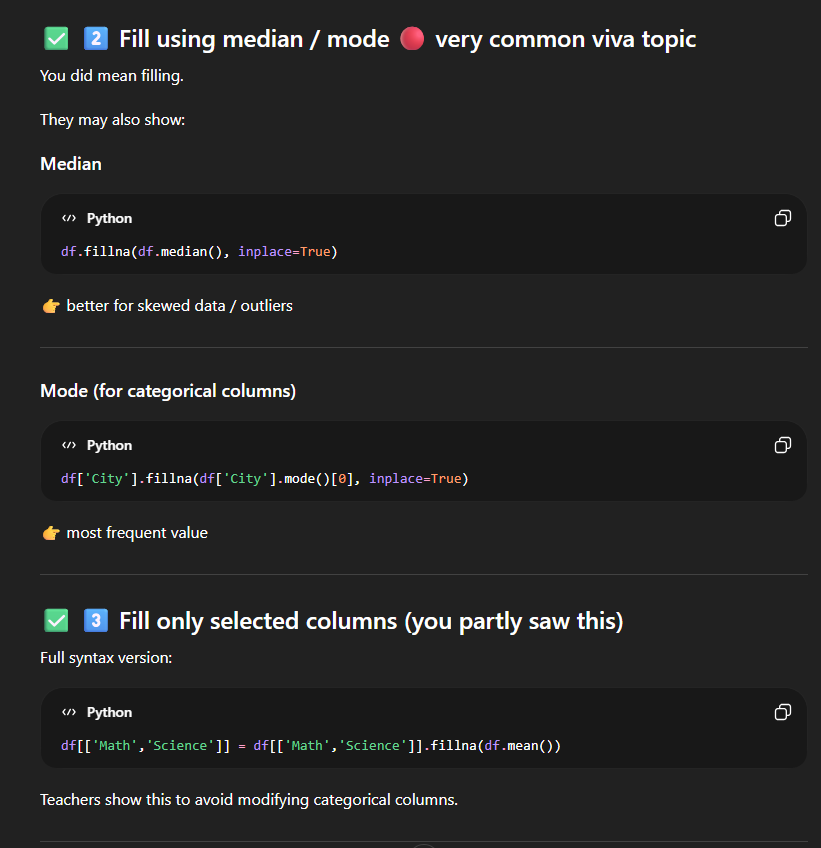

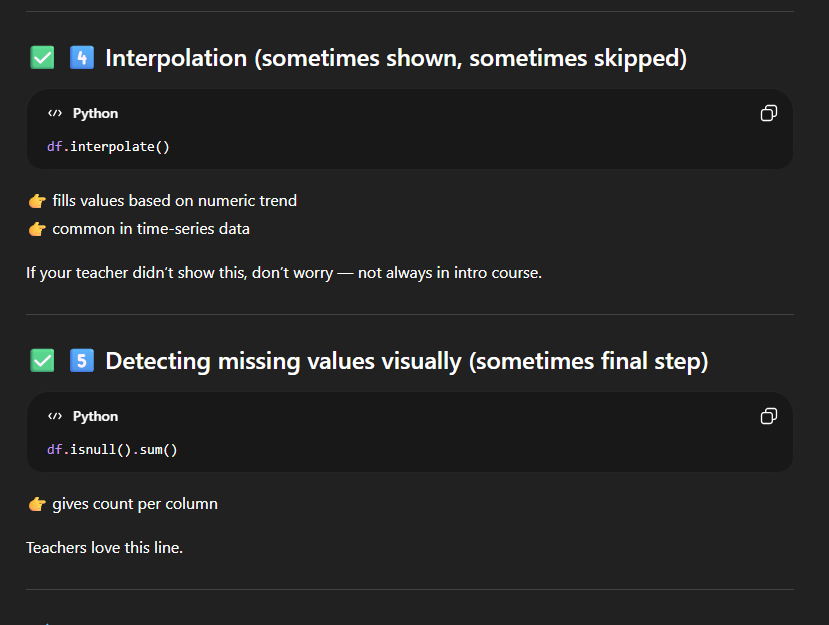